# 3F8 Inference: Coursework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cbl-cambridge/3F8-Lab/blob/main/coursework.ipynb)

This is the auxiliary code for the 3F8 coursework. Some parts are missing and should be completed by the student. These are marked with `XXX`.

## How to Use This Notebook

This notebook is divided into **cells** containing either code or text. To work through the coursework, run each code cell from top to bottom using these keyboard shortcuts:

- **Shift+Enter** — Run the current cell and move to the next one
- **Ctrl+Enter** — Run the current cell and stay on it (useful for re-running a cell after changing a parameter)

Cells can be run in any order, but each cell may depend on variables or functions defined in earlier cells. When working through the notebook for the first time, it is simplest to run cells from top to bottom. If you go back and change a cell, make sure to re-run it and any later cells that depend on it.

You can use the **+ Code** / **+ Text** buttons that appear below each cell when you hover to add a new cell (useful for experimenting or adding your own notes).

## Setup

The coursework requires two data files: `X.txt` and `y.txt`.

**Option 1 (recommended):** Run the cell below to download them automatically from GitHub.

In [2]:
import urllib.request

base_url = "https://raw.githubusercontent.com/cbl-cambridge/3F8-Lab/main/"
for filename in ["X.txt", "y.txt"]:
    urllib.request.urlretrieve(base_url + filename, filename)
    print(f"Downloaded {filename}")

Downloaded X.txt
Downloaded y.txt


**Option 2:** Upload the files manually. In Google Colab:
1. Click the **files icon** (folder) in the left sidebar
2. Click the **upload icon** at the top of the file browser
3. Select `X.txt` and `y.txt` from your computer

<img src="https://raw.githubusercontent.com/cbl-cambridge/3F8-Lab/main/Colab%20Upload%20Instructions.png" width="300">

## Load and Visualise the Data

In [ ]:
# We load the data

import numpy as np

X = np.loadtxt('X.txt')
y = np.loadtxt('y.txt')

In [ ]:
# We randomly permute the data

permutation = np.random.permutation(X.shape[ 0 ])
X = X[ permutation, : ]
y = y[ permutation ]

In [ ]:
# We plot the data

import matplotlib.pyplot as plt

##
# Function that plots the points in 2D together with their labels
#
# Inputs:
#
# X: 2d array with the input features
# y: 1d array with the class labels (0 or 1)
#
# Output: 2D matrices with the x and y coordinates of the points shown in the plot
#

def plot_data_internal(X, y):
    x_min, x_max = X[ :, 0 ].min() - .5, X[ :, 0 ].max() + .5
    y_min, y_max = X[ :, 1 ].min() - .5, X[ :, 1 ].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    plt.figure()
    plt.xlim(xx.min(None), xx.max(None))
    plt.ylim(yy.min(None), yy.max(None))
    ax = plt.gca()
    ax.plot(X[y == 0, 0], X[y == 0, 1], 'ro', label = 'Class 1')
    ax.plot(X[y == 1, 0], X[y == 1, 1], 'bo', label = 'Class 2')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Plot data')
    plt.legend(loc = 'upper left', scatterpoints = 1, numpoints = 1)
    return xx, yy

##
# Function that plots the data without returning anything by calling "plot_data_internal".
#
# Input:
#
# X: 2d array with the input features
# y: 1d array with the class labels (0 or 1)
#
# Output: Nothing.
#

def plot_data(X, y):
    xx, yy = plot_data_internal(X, y)
    plt.show()

In [ ]:
plot_data(X, y)

## Train/Test Split and Model Functions

In [ ]:
# We split the data into train and test sets

n_train = 800
X_train = X[ 0 : n_train, : ]
X_test = X[ n_train :, : ]
y_train = y[ 0 : n_train ]
y_test = y[ n_train : ]

In [ ]:
# The logistic function

def logistic(x): return 1.0 / (1.0 + np.exp(-x))

##
# Function that makes predictions with a logistic classifier
#
# Input:
#
# X_tile: matrix of input features (with a constant 1 appended to the left)
#         for which to make predictions
# w: vector of model parameters
#
# Output: The predictions of the logistic classifier
#

def predict(X_tilde, w): return logistic(np.dot(X_tilde, w))

##
# Function that computes the average loglikelihood of the logistic classifier on some data.
#
# Input:
#
# X_tile: matrix of input features (with a constant 1 appended to the left)
#         for which to make predictions
# y: vector of binary output labels
# w: vector of model parameters
#
# Output: The average loglikelihood
#

def compute_average_ll(X_tilde, y, w):
    output_prob = predict(X_tilde, w)
    return np.mean(y * np.log(output_prob) + (1 - y) * np.log(1.0 - output_prob))

##
# Function that expands a matrix of input features by adding a column equal to 1.
#
# Input:
#
# X: matrix of input features.
#
# Output: Matrix x_tilde with one additional constant column equal to 1 added.
#

def get_x_tilde(X): return np.concatenate((np.ones((X.shape[ 0 ], 1 )), X), 1)

## Training the Logistic Classifier

In [ ]:
##
# Function that finds the model parameters by optimising the likelihood using gradient descent
#
# Input:
#
# X_tile_train: matrix of training input features (with a constant 1 appended to the left)
# y_train: vector of training binary output labels
# X_tile_test: matrix of test input features (with a constant 1 appended to the left)
# y_test: vector of test binary output labels
# alpha: step_size_parameter for the gradient based optimisation
# n_steps: the number of steps of gradient based optimisation
#
# Output:
#
# 1 - Vector of model parameters w
# 2 - Vector with average log-likelihood values obtained on the training set
# 3 - Vector with average log-likelihood values obtained on the test set
#

def fit_w(X_tilde_train, y_train, X_tilde_test, y_test, n_steps, alpha):
    w = np.random.randn(X_tilde_train.shape[ 1 ])
    ll_train = np.zeros(n_steps)
    ll_test = np.zeros(n_steps)
    for i in range(n_steps):
        sigmoid_value = predict(X_tilde_train, w)

        w = # XXX Gradient-based update rule for w. To be completed by the student

        ll_train[ i ] = compute_average_ll(X_tilde_train, y_train, w)
        ll_test[ i ] = compute_average_ll(X_tilde_test, y_test, w)
        print(ll_train[ i ], ll_test[ i ])

    return w, ll_train, ll_test

In [ ]:
# We train the classifier

alpha = # XXX Learning rate for gradient-based optimisation. To be completed by the student
n_steps = # XXX Number of steps of gradient-based optimisation. To be completed by the student

X_tilde_train = get_x_tilde(X_train)
X_tilde_test = get_x_tilde(X_test)
w, ll_train, ll_test = fit_w(X_tilde_train, y_train, X_tilde_test, y_test, n_steps, alpha)

## Plotting the Results

In [ ]:
##
# Function that plots the average log-likelihood returned by "fit_w"
#
# Input:
#
# ll: vector with log-likelihood values
#
# Output: Nothing
#

def plot_ll(ll):
    plt.figure()
    ax = plt.gca()
    plt.xlim(0, len(ll) + 2)
    plt.ylim(min(ll) - 0.1, max(ll) + 0.1)
    ax.plot(np.arange(1, len(ll) + 1), ll, 'r-')
    plt.xlabel('Steps')
    plt.ylabel('Average log-likelihood')
    plt.title('Plot Average Log-likelihood Curve')
    plt.show()

In [ ]:
# We plot the training and test log likelihoods

plot_ll(ll_train)
plot_ll(ll_test)

In [ ]:
##
# Function that plots the predictive probabilities of the logistic classifier
#
# Input:
#
# X: 2d array with the input features for the data (without adding a constant column with ones at the beginning)
# y: 1d array with the class labels (0 or 1) for the data
# w: parameter vector
# map_inputs: function that expands the original 2D inputs using basis functions.
#
# Output: Nothing.
#

def plot_predictive_distribution(X, y, w, map_inputs = lambda x : x):
    xx, yy = plot_data_internal(X, y)
    ax = plt.gca()
    X_tilde = get_x_tilde(map_inputs(np.concatenate((xx.ravel().reshape((-1, 1)), yy.ravel().reshape((-1, 1))), 1)))
    Z = predict(X_tilde, w)
    Z = Z.reshape(xx.shape)
    cs2 = ax.contour(xx, yy, Z, cmap = 'RdBu', linewidths = 2)
    plt.clabel(cs2, fmt = '%2.1f', colors = 'k', fontsize = 14)
    plt.show()

In [ ]:
# We plot the predictive distribution

plot_predictive_distribution(X, y, w)

## Non-Linear Feature Expansion with Radial Basis Functions

In [ ]:
##
# Function that replaces initial input features by evaluating Gaussian basis functions
# on a grid of points
#
# Inputs:
#
# l: hyper-parameter for the width of the Gaussian basis functions
# Z: location of the Gaussian basis functions
# X: points at which to evaluate the basis functions
#
# Output: Feature matrix with the evaluations of the Gaussian basis functions.
#

def evaluate_basis_functions(l, X, Z):
    X2 = np.sum(X**2, 1)
    Z2 = np.sum(Z**2, 1)
    ones_Z = np.ones(Z.shape[ 0 ])
    ones_X = np.ones(X.shape[ 0 ])
    r2 = np.outer(X2, ones_Z) - 2 * np.dot(X, Z.T) + np.outer(ones_X, Z2)
    return np.exp(-0.5 / l**2 * r2)

In [ ]:
# We expand the data

l = # XXX Width of the Gaussian basis funcction. To be completed by the student

X_tilde_train = get_x_tilde(evaluate_basis_functions(l, X_train, X_train))
X_tilde_test = get_x_tilde(evaluate_basis_functions(l, X_test, X_train))

In [ ]:
# We train the new classifier on the feature expanded inputs

alpha = # XXX Learning rate for gradient-based optimisation with basis functions. To be completed by the student
n_steps = # XXX Number of steps of gradient-based optimisation with basis functions. To be completed by the student

w, ll_train, ll_test = fit_w(X_tilde_train, y_train, X_tilde_test, y_test, n_steps, alpha)

In [ ]:
# We plot the training and test log likelihoods

plot_ll(ll_train)
plot_ll(ll_test)

In [ ]:
# We plot the predictive distribution

plot_predictive_distribution(X, y, w, lambda x : evaluate_basis_functions(l, x, X_train))

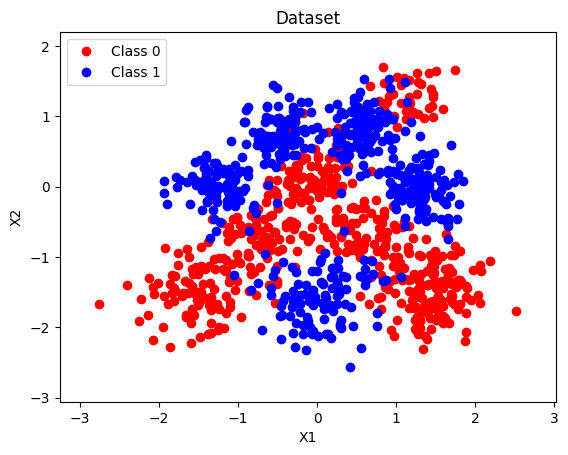


Results baseline  sigma2_0=1.0, l=0.1

Log evidence:
-311.89975961802895

Average log-likelihoods
Train LL (MAP): -0.20923460108300992
Test LL (MAP): -0.336076966584764
Train LL (Laplace): -0.24947249052845483
Test LL (Laplace): -0.35595744321735895

Train confusion matrix MAP (counts)
[[386  17]
 [ 21 376]]

Test confusion matrix MAP (counts)
[[93 10]
 [17 80]]

Train confusion matrix Laplace (counts)
[[386  17]
 [ 21 376]]

Test confusion matrix Laplace (counts)
[[93 10]
 [17 80]]

Train confusion matrix MAP (%)
[[48.25   2.125]
 [ 2.625 47.   ]]

Test confusion matrix MAP (%)
[[46.5  5. ]
 [ 8.5 40. ]]

Train confusion matrix Laplace (%)
[[48.25   2.125]
 [ 2.625 47.   ]]

Test confusion matrix Laplace (%)
[[46.5  5. ]
 [ 8.5 40. ]]

Max abs diff train probs: 0.05301127384896498
Max abs diff test probs : 0.04871583224419185


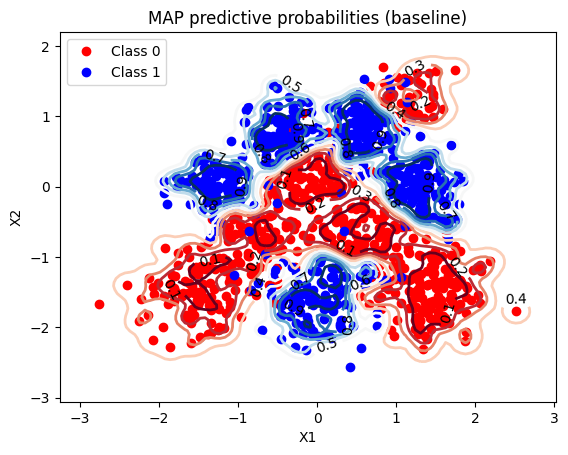

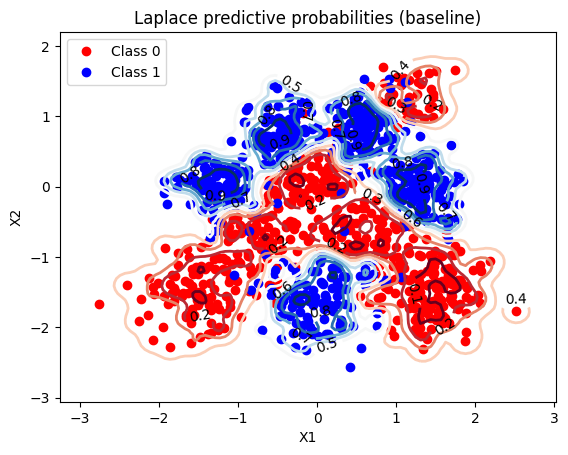


Grid search results
Best sigma2_0: 0.8
Best l: 0.5
Best log evidence: -179.22652838407174


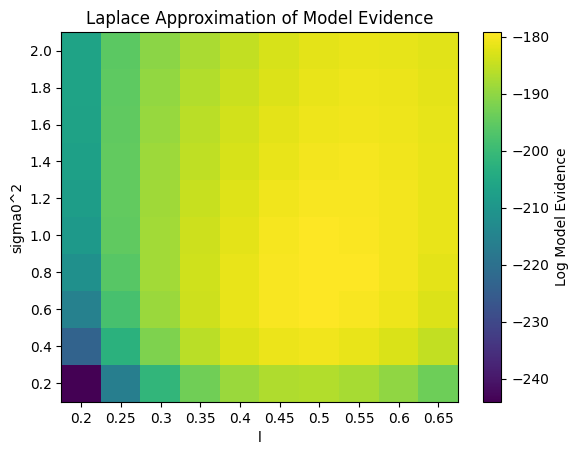


Results tuned  sigma2_0=0.8, l=0.5

Log evidence:
-179.22652838407174

Average log-likelihoods
Train LL (MAP): -0.16646674555154323
Test LL (MAP): -0.2585223976528077
Train LL (Laplace): -0.17513600324161502
Test LL (Laplace): -0.2536677996484521

Train confusion matrix MAP (counts)
[[378  25]
 [ 29 368]]

Test confusion matrix MAP (counts)
[[92 11]
 [ 9 88]]

Train confusion matrix Laplace (counts)
[[378  25]
 [ 29 368]]

Test confusion matrix Laplace (counts)
[[92 11]
 [ 9 88]]

Train confusion matrix MAP (%)
[[47.25   3.125]
 [ 3.625 46.   ]]

Test confusion matrix MAP (%)
[[46.   5.5]
 [ 4.5 44. ]]

Train confusion matrix Laplace (%)
[[47.25   3.125]
 [ 3.625 46.   ]]

Test confusion matrix Laplace (%)
[[46.   5.5]
 [ 4.5 44. ]]

Max abs diff train probs: 0.05886594634255726
Max abs diff test probs : 0.05471571553488308


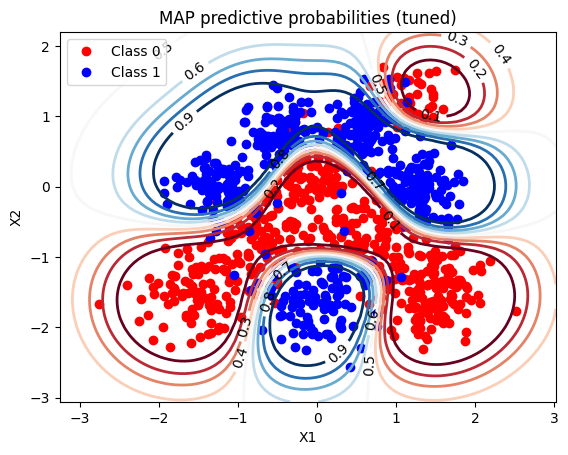

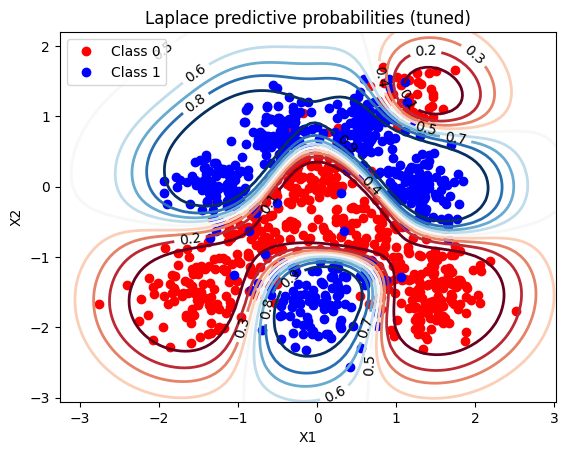


Comparison: baseline vs tuned

Baseline hyperparameters:
sigma2_0 = 1.0 , l = 0.1

Tuned hyperparameters:
sigma2_0 = 0.8 , l = 0.5

Baseline log evidence: -311.89975961802895
Tuned log evidence   : -179.22652838407174

Baseline test LL (Laplace): -0.35595744321735895
Tuned test LL (Laplace)   : -0.2536677996484521

Baseline test confusion matrix Laplace (%)
[[46.5  5. ]
 [ 8.5 40. ]]

Tuned test confusion matrix Laplace (%)
[[46.   5.5]
 [ 4.5 44. ]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin_l_bfgs_b

# ============================================================
# Load and shuffle data
# ============================================================

X = np.loadtxt('X.txt')
y = np.loadtxt('y.txt').astype(int)

np.random.seed(0)
permutation = np.random.permutation(X.shape[0])
X = X[permutation, :]
y = y[permutation]

# Train/test split
n_train = 800
X_train = X[:n_train, :]
X_test = X[n_train:, :]
y_train = y[:n_train]
y_test = y[n_train:]

# ============================================================
# Basic plotting helpers
# ============================================================

def plot_data_internal(X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    plt.figure()
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    ax = plt.gca()
    ax.plot(X[y == 0, 0], X[y == 0, 1], 'ro', label='Class 0')
    ax.plot(X[y == 1, 0], X[y == 1, 1], 'bo', label='Class 1')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Dataset')
    plt.legend(loc='upper left')

    return xx, yy

def plot_data(X, y):
    plot_data_internal(X, y)
    plt.show()

# ============================================================
# Logistic model helpers
# ============================================================

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def get_x_tilde(X):
    return np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

def predict(X_tilde, w):
    return logistic(X_tilde @ w)

def compute_average_ll(X_tilde, y, w):
    probs = predict(X_tilde, w)
    probs = np.clip(probs, 1e-12, 1 - 1e-12)
    return np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))

def compute_average_ll_probs(y, probs):
    probs = np.clip(probs, 1e-12, 1 - 1e-12)
    return np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))

# ============================================================
# RBF feature expansion
# ============================================================

def evaluate_basis_functions(l, X, Z):
    X2 = np.sum(X**2, axis=1)
    Z2 = np.sum(Z**2, axis=1)
    ones_Z = np.ones(Z.shape[0])
    ones_X = np.ones(X.shape[0])
    r2 = np.outer(X2, ones_Z) - 2 * (X @ Z.T) + np.outer(ones_X, Z2)
    return np.exp(-0.5 / (l**2) * r2)

# ============================================================
# MAP objective and gradient
# ============================================================

def negative_log_posterior(w, X_tilde, y, sigma2_0):
    probs = predict(X_tilde, w)
    probs = np.clip(probs, 1e-12, 1 - 1e-12)

    # Negative log-likelihood
    nll = -np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

    # Negative log-prior (ignoring additive constants)
    nlprior = 0.5 / sigma2_0 * np.sum(w**2)

    return nll + nlprior

def gradient_negative_log_posterior(w, X_tilde, y, sigma2_0):
    probs = predict(X_tilde, w)

    grad_nll = X_tilde.T @ (probs - y)
    grad_prior = (1.0 / sigma2_0) * w

    return grad_nll + grad_prior

def fit_w_map(X_tilde_train, y_train, sigma2_0):
    w0 = np.zeros(X_tilde_train.shape[1])

    result = fmin_l_bfgs_b(
        func=negative_log_posterior,
        x0=w0,
        fprime=gradient_negative_log_posterior,
        args=(X_tilde_train, y_train, sigma2_0)
    )

    w_map = result[0]
    return w_map

# ============================================================
# Laplace approximation
# ============================================================

def compute_hessian(w_map, X_tilde, sigma2_0):
    probs = predict(X_tilde, w_map)
    R = probs * (1.0 - probs)  # shape (N,)

    # Phi^T R Phi + sigma0^{-2} I
    H = (X_tilde.T * R) @ X_tilde + (1.0 / sigma2_0) * np.eye(X_tilde.shape[1])
    return H

def compute_posterior_covariance(w_map, X_tilde, sigma2_0):
    H = compute_hessian(w_map, X_tilde, sigma2_0)
    return np.linalg.inv(H)

def kappa(sigma2):
    return (1.0 + np.pi * sigma2 / 8.0) ** (-0.5)

def predict_laplace(X_tilde, w_map, S_N):
    mu_a = X_tilde @ w_map
    sigma2_a = np.sum((X_tilde @ S_N) * X_tilde, axis=1)
    return logistic(kappa(sigma2_a) * mu_a)

def compute_log_evidence(X_tilde, y, w_map, sigma2_0):
    probs = predict(X_tilde, w_map)
    probs = np.clip(probs, 1e-12, 1 - 1e-12)

    log_lik = np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

    M = len(w_map)
    log_prior = -0.5 * np.sum(w_map**2) / sigma2_0 - (M / 2.0) * np.log(2 * np.pi * sigma2_0)

    H = compute_hessian(w_map, X_tilde, sigma2_0)
    sign, logdetH = np.linalg.slogdet(H)
    if sign <= 0:
        raise ValueError("Hessian is not positive definite.")

    log_evidence = log_lik + log_prior + (M / 2.0) * np.log(2 * np.pi) - 0.5 * logdetH
    return log_evidence

# ============================================================
# Confusion matrices
# ============================================================

def confusion_matrix_counts(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)

    tn = np.sum((y_true == 0) & (preds == 0))
    fp = np.sum((y_true == 0) & (preds == 1))
    fn = np.sum((y_true == 1) & (preds == 0))
    tp = np.sum((y_true == 1) & (preds == 1))

    return np.array([[tn, fp],
                     [fn, tp]])

def confusion_matrix_percent(y_true, probs, threshold=0.5):
    cm = confusion_matrix_counts(y_true, probs, threshold)
    return 100.0 * cm / len(y_true)

# ============================================================
# Predictive contour plots
# ============================================================

def plot_predictive_distribution_map(X, y, w_map, map_inputs=lambda x: x, title='MAP predictive probabilities'):
    xx, yy = plot_data_internal(X, y)
    ax = plt.gca()

    X_grid = np.concatenate(
        (xx.ravel().reshape((-1, 1)), yy.ravel().reshape((-1, 1))),
        axis=1
    )

    X_tilde_grid = get_x_tilde(map_inputs(X_grid))
    Z = predict(X_tilde_grid, w_map)
    Z = Z.reshape(xx.shape)

    cs = ax.contour(xx, yy, Z, levels=np.linspace(0.1, 0.9, 9), cmap='RdBu', linewidths=2)
    plt.clabel(cs, fmt='%0.1f', colors='k', fontsize=10)
    plt.title(title)
    plt.show()

def plot_predictive_distribution_laplace(X, y, w_map, S_N, map_inputs=lambda x: x, title='Laplace predictive probabilities'):
    xx, yy = plot_data_internal(X, y)
    ax = plt.gca()

    X_grid = np.concatenate(
        (xx.ravel().reshape((-1, 1)), yy.ravel().reshape((-1, 1))),
        axis=1
    )

    X_tilde_grid = get_x_tilde(map_inputs(X_grid))
    Z = predict_laplace(X_tilde_grid, w_map, S_N)
    Z = Z.reshape(xx.shape)

    cs = ax.contour(xx, yy, Z, levels=np.linspace(0.1, 0.9, 9), cmap='RdBu', linewidths=2)
    plt.clabel(cs, fmt='%0.1f', colors='k', fontsize=10)
    plt.title(title)
    plt.show()

# ============================================================
# Helper: train + evaluate model for given sigma2_0 and l
# ============================================================

def train_and_evaluate_model(X_train, y_train, X_test, y_test, sigma2_0, l, make_plots=True, label=''):
    # RBF feature expansion
    X_train_rbf = evaluate_basis_functions(l, X_train, X_train)
    X_test_rbf = evaluate_basis_functions(l, X_test, X_train)

    X_tilde_train = get_x_tilde(X_train_rbf)
    X_tilde_test = get_x_tilde(X_test_rbf)

    # MAP
    w_map = fit_w_map(X_tilde_train, y_train, sigma2_0)

    # Laplace covariance
    S_N = compute_posterior_covariance(w_map, X_tilde_train, sigma2_0)

    # Probabilities
    train_probs_map = predict(X_tilde_train, w_map)
    test_probs_map = predict(X_tilde_test, w_map)

    train_probs_laplace = predict_laplace(X_tilde_train, w_map, S_N)
    test_probs_laplace = predict_laplace(X_tilde_test, w_map, S_N)

    # Log-likelihoods
    train_ll_map = compute_average_ll_probs(y_train, train_probs_map)
    test_ll_map = compute_average_ll_probs(y_test, test_probs_map)

    train_ll_laplace = compute_average_ll_probs(y_train, train_probs_laplace)
    test_ll_laplace = compute_average_ll_probs(y_test, test_probs_laplace)

    # Confusion matrices
    cm_train_map_counts = confusion_matrix_counts(y_train, train_probs_map)
    cm_test_map_counts = confusion_matrix_counts(y_test, test_probs_map)

    cm_train_laplace_counts = confusion_matrix_counts(y_train, train_probs_laplace)
    cm_test_laplace_counts = confusion_matrix_counts(y_test, test_probs_laplace)

    cm_train_map_pct = confusion_matrix_percent(y_train, train_probs_map)
    cm_test_map_pct = confusion_matrix_percent(y_test, test_probs_map)

    cm_train_laplace_pct = confusion_matrix_percent(y_train, train_probs_laplace)
    cm_test_laplace_pct = confusion_matrix_percent(y_test, test_probs_laplace)

    # Evidence
    log_evidence = compute_log_evidence(X_tilde_train, y_train, w_map, sigma2_0)

    # Print summary
    print('\n' + '=' * 60)
    print(f'Results {label}  sigma2_0={sigma2_0}, l={l}')
    print('=' * 60)

    print('\nLog evidence:')
    print(log_evidence)

    print('\nAverage log-likelihoods')
    print('Train LL (MAP):', train_ll_map)
    print('Test LL (MAP):', test_ll_map)
    print('Train LL (Laplace):', train_ll_laplace)
    print('Test LL (Laplace):', test_ll_laplace)

    print('\nTrain confusion matrix MAP (counts)')
    print(cm_train_map_counts)
    print('\nTest confusion matrix MAP (counts)')
    print(cm_test_map_counts)

    print('\nTrain confusion matrix Laplace (counts)')
    print(cm_train_laplace_counts)
    print('\nTest confusion matrix Laplace (counts)')
    print(cm_test_laplace_counts)

    print('\nTrain confusion matrix MAP (%)')
    print(cm_train_map_pct)
    print('\nTest confusion matrix MAP (%)')
    print(cm_test_map_pct)

    print('\nTrain confusion matrix Laplace (%)')
    print(cm_train_laplace_pct)
    print('\nTest confusion matrix Laplace (%)')
    print(cm_test_laplace_pct)

    # Probability difference sanity check
    print('\nMax abs diff train probs:', np.max(np.abs(train_probs_map - train_probs_laplace)))
    print('Max abs diff test probs :', np.max(np.abs(test_probs_map - test_probs_laplace)))

    # Plots
    if make_plots:
        plot_predictive_distribution_map(
            X, y, w_map,
            map_inputs=lambda x: evaluate_basis_functions(l, x, X_train),
            title=f'MAP predictive probabilities ({label})'
        )

        plot_predictive_distribution_laplace(
            X, y, w_map, S_N,
            map_inputs=lambda x: evaluate_basis_functions(l, x, X_train),
            title=f'Laplace predictive probabilities ({label})'
        )

    return {
        'sigma2_0': sigma2_0,
        'l': l,
        'w_map': w_map,
        'S_N': S_N,
        'log_evidence': log_evidence,
        'train_ll_map': train_ll_map,
        'test_ll_map': test_ll_map,
        'train_ll_laplace': train_ll_laplace,
        'test_ll_laplace': test_ll_laplace,
        'cm_train_map_counts': cm_train_map_counts,
        'cm_test_map_counts': cm_test_map_counts,
        'cm_train_laplace_counts': cm_train_laplace_counts,
        'cm_test_laplace_counts': cm_test_laplace_counts,
        'cm_train_map_pct': cm_train_map_pct,
        'cm_test_map_pct': cm_test_map_pct,
        'cm_train_laplace_pct': cm_train_laplace_pct,
        'cm_test_laplace_pct': cm_test_laplace_pct
    }

# ============================================================
# Exercise c/d with fixed hyperparameters
# ============================================================

plot_data(X, y)

baseline_sigma2_0 = 1.0
baseline_l = 0.1

baseline_results = train_and_evaluate_model(
    X_train, y_train, X_test, y_test,
    sigma2_0=baseline_sigma2_0,
    l=baseline_l,
    make_plots=True,
    label='baseline'
)

# ============================================================
# Exercise e: grid search on log evidence
# ============================================================

sigma2_values = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
l_values = np.array([0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65])

evidence_grid = np.zeros((len(sigma2_values), len(l_values)))

for i, sigma2_0 in enumerate(sigma2_values):
    for j, l in enumerate(l_values):
        X_train_rbf = evaluate_basis_functions(l, X_train, X_train)
        X_tilde_train = get_x_tilde(X_train_rbf)

        w_map = fit_w_map(X_tilde_train, y_train, sigma2_0)
        log_evidence = compute_log_evidence(X_tilde_train, y_train, w_map, sigma2_0)

        evidence_grid[i, j] = log_evidence

best_idx = np.unravel_index(np.argmax(evidence_grid), evidence_grid.shape)
best_sigma2 = sigma2_values[best_idx[0]]
best_l = l_values[best_idx[1]]

print('\n' + '=' * 60)
print('Grid search results')
print('=' * 60)
print('Best sigma2_0:', best_sigma2)
print('Best l:', best_l)
print('Best log evidence:', evidence_grid[best_idx])

plt.figure()
plt.imshow(evidence_grid, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Log Model Evidence')
plt.xticks(range(len(l_values)), l_values)
plt.yticks(range(len(sigma2_values)), sigma2_values)
plt.xlabel('l')
plt.ylabel('sigma0^2')
plt.title('Laplace Approximation of Model Evidence')
plt.show()

# ============================================================
# Exercise f: retrain with tuned hyperparameters
# ============================================================

tuned_results = train_and_evaluate_model(
    X_train, y_train, X_test, y_test,
    sigma2_0=best_sigma2,
    l=best_l,
    make_plots=True,
    label='tuned'
)

# ============================================================
# Compare baseline vs tuned
# ============================================================

print('\n' + '=' * 60)
print('Comparison: baseline vs tuned')
print('=' * 60)

print('\nBaseline hyperparameters:')
print('sigma2_0 =', baseline_results['sigma2_0'], ', l =', baseline_results['l'])

print('\nTuned hyperparameters:')
print('sigma2_0 =', tuned_results['sigma2_0'], ', l =', tuned_results['l'])

print('\nBaseline log evidence:', baseline_results['log_evidence'])
print('Tuned log evidence   :', tuned_results['log_evidence'])

print('\nBaseline test LL (Laplace):', baseline_results['test_ll_laplace'])
print('Tuned test LL (Laplace)   :', tuned_results['test_ll_laplace'])

print('\nBaseline test confusion matrix Laplace (%)')
print(baseline_results['cm_test_laplace_pct'])

print('\nTuned test confusion matrix Laplace (%)')
print(tuned_results['cm_test_laplace_pct'])